In [28]:
# 사용하는 최상위 폴더를 변수로 하나 선언

ROOT_FOLDER = '/home/govlept1004/jupyter_home/TF2_Object_Detection'

In [ ]:
# 폴더 생성

!mkdir $ROOT_FOLDER/models/research/FIREdevkit
!mkdir $ROOT_FOLDER/models/research/FIREdevkit/Annotations
!mkdir $ROOT_FOLDER/models/research/FIREdevkit/ImageSets
!mkdir $ROOT_FOLDER/models/research/FIREdevkit/JPEGImages
!mkdir $ROOT_FOLDER/models/research/FIREdevkit/ImageSets/Main

In [ ]:
# ImageSets/Main에 train.txt, val.txt 파일명 리스트 들은 파일 생성

import os

# 대상 폴더
folder_path = "/home/govlept1004/jupyter_home/TF2_Object_Detection/models/research/fire-dataset/train/images"
# 저장할 파일 경로
output_file = "/home/govlept1004/jupyter_home/TF2_Object_Detection/models/research/FIREdevkit/ImageSets/Main/train.txt"

# 확장자 제거 후, 파일명만 리스트로 저장
file_names = [
    os.path.splitext(f)[0]
    for f in os.listdir(folder_path)
    if os.path.isfile(os.path.join(folder_path, f))
]

# 텍스트 파일로 저장
with open(output_file, "w") as f:
    for name in sorted(file_names):  # optional: 정렬하고 싶으면 sorted() 사용
        f.write(name + "\n")

In [33]:
# validation도 파일명 리스트 파일 만들기

# 대상 폴더
folder_path = "/home/govlept1004/jupyter_home/TF2_Object_Detection/models/research/fire-dataset/validation/images"
# 저장할 파일 경로
output_file = "/home/govlept1004/jupyter_home/TF2_Object_Detection/models/research/FIREdevkit/ImageSets/Main/val.txt"

# 확장자 제거 후, 파일명만 리스트로 저장
file_names = [
    os.path.splitext(f)[0]
    for f in os.listdir(folder_path)
    if os.path.isfile(os.path.join(folder_path, f))
]

# 텍스트 파일로 저장
with open(output_file, "w") as f:
    for name in sorted(file_names):  # optional: 정렬하고 싶으면 sorted() 사용
        f.write(name + "\n")

In [ ]:
# FIREdevkit에 fire-dataset 파일들 복사하기
cd $ROOT_FOLDER/models/research

/home/govlept1004/jupyter_home/TF2_Object_Detection/models/research


In [35]:
!cp -r $ROOT_FOLDER/models/research/fire-dataset/train/annotations/* $ROOT_FOLDER/models/research/FIREdevkit/Annotations

In [36]:
!cp -r $ROOT_FOLDER/models/research/fire-dataset/train/images/* $ROOT_FOLDER/models/research/FIREdevkit/JPEGImages

In [37]:
!cp -r $ROOT_FOLDER/models/research/fire-dataset/validation/annotations/* $ROOT_FOLDER/models/research/FIREdevkit/Annotations

In [38]:
!cp -r $ROOT_FOLDER/models/research/fire-dataset/validation/images/* $ROOT_FOLDER/models/research/FIREdevkit/JPEGImages

In [ ]:
# class이름이 명시된 .pbtxt 파일을 하나 생성

voc_classes = [
    "fire"
]

with open("fire_label_map.pbtxt", "w") as f:
    for idx, class_name in enumerate(voc_classes, 1):
        f.write("item {\n")
        f.write(f"  id: {idx}\n")
        f.write(f"  name: '{class_name}'\n")
        f.write("}\n\n")

In [ ]:
# TFRecord를 생성하는 python 프로그램도 생겼으니 이제 해당 코드를 이용해서 pascal voc data를 TFRecord로 변환시켜 보아요!
# TFRecord 생성하는 명령(train)
!python ./create_fire_pascal_tf_record.py --data_dir=FIREdevkit --set=train --output_path=./fire_pascal_train.tfrecord --label_map_path=./fire_label_map.pbtxt

TFRecord 생성 완료: ./fire_pascal_train.tfrecord


In [43]:
# TFRecord 생성하는 명령(validation)
!python ./create_fire_pascal_tf_record.py --data_dir=FIREdevkit --set=val --output_path=./fire_pascal_val.tfrecord --label_map_path=./fire_label_map.pbtxt

TFRecord 생성 완료: ./fire_pascal_val.tfrecord


우리가 사용하는 모델은 faster-RCNN 모델을 이용

학습을 하기 위해서 디렉토리 구조를 만들어야 해요!
TF2_Object_Detection/fire_od_model/
    - data/
        이 데이터 폴더안에 pbtxt(클래스명), 2개의 TFRecord
    - models/
        - pascal_voc_model/
            my_fire_model.config(설정파일)

In [44]:
!pwd

/home/govlept1004/jupyter_home/TF2_Object_Detection/models/research


In [45]:
!mkdir $ROOT_FOLDER/fire_od_model/data
!mkdir $ROOT_FOLDER/fire_od_model/models

In [46]:
!mkdir $ROOT_FOLDER/fire_od_model/models/pascal_voc_model

In [47]:
!cp $ROOT_FOLDER/models/research/fire_label_map.pbtxt $ROOT_FOLDER/fire_od_model/data
!cp $ROOT_FOLDER/models/research/fire_pascal_train.tfrecord $ROOT_FOLDER/fire_od_model/data
!cp $ROOT_FOLDER/models/research/fire_pascal_val.tfrecord $ROOT_FOLDER/fire_od_model/data

# model configuration file 생성

In [50]:
!cp -r $ROOT_FOLDER/pretrained_model/faster_rcnn_resnet101_v1_800x1333_coco17_gpu-8/checkpoint $ROOT_FOLDER/fire_od_model

In [51]:
# 학습을 해 보아요!
!python object_detection/model_main_tf2.py --pipeline_config_path=$ROOT_FOLDER/fire_od_model/models/pascal_voc_model/my_fire_model.config --model_dir=$ROOT_FOLDER/fire_od_model/models/pascal_voc_model --alsologtostderr

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
I0509 15:59:44.092207 140488514212480 mirrored_strategy.py:419] Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
INFO:tensorflow:Maybe overwriting train_steps: None
I0509 15:59:44.365137 140488514212480 config_util.py:552] Maybe overwriting train_steps: None
INFO:tensorflow:Maybe overwriting use_bfloat16: False
I0509 15:59:44.365292 140488514212480 config_util.py:552] Maybe overwriting use_bfloat16: False
Instructions for updating:
rename to distribute_datasets_from_function
W0509 15:59:44.389450 140488514212480 deprecation.py:364] From /home/govlept1004/anaconda3/envs/tf_env/lib/python3.10/site-packages/object_detection/model_lib_v2.py:563: StrategyBase.experimental_distribute_datasets_from_function (from tensorflow.python.distribute.distribute_lib) is deprecated and will be removed in a future version.
Instructions for updating:
rename to distribu

In [52]:
# import

import os
import io
import scipy.misc
import numpy as np
from six import BytesIO
from PIL import Image, ImageDraw, ImageFont
from IPython.display import Image as ipython_image

import tensorflow as tf

from object_detection.utils import label_map_util
from object_detection.utils import config_util
from object_detection.utils import visualization_utils as viz_utils
from object_detection.builders import model_builder

/tmp/ipykernel_34800/4235086641.py:5: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  import scipy.misc


In [53]:
# Utilities

def load_image_into_numpy_array(path):
  # Load an image from file into a numpy array.

  # Args:   
  #  path: the file path to the image

  # Returns:
  #  uint8 numpy array with shape (img_height, img_width, 3)
    img_data = tf.io.gfile.GFile(path, 'rb').read()
    image = Image.open(BytesIO(img_data))
    (im_width, im_height) = image.size
    return np.array(image.getdata()).reshape((im_height, im_width, 3)).astype(np.uint8)


def get_keypoint_tuples(eval_config):
  # Return a tuple list of keypoint edges from the eval config.
  
  # Args:
  #  eval_config: an eval config containing the keypoint edges
  
  # Returns:
  #  a list of edge tuples, each in the format (start, end)
    tuple_list = []
    kp_list = eval_config.keypoint_edge
    for edge in kp_list:
        tuple_list.append((edge.start, edge.end))
    return tuple_list

In [55]:
# Build a detection model and load pre-trained model weights

pipeline_config = ROOT_FOLDER + '/fire_od_model/models/pascal_voc_model/my_fire_model.config'
model_dir = ROOT_FOLDER + '/fire_od_model/models/pascal_voc_model'

# Load pipeline config and build a detection model
configs = config_util.get_configs_from_pipeline_file(pipeline_config)
model_config = configs['model']
detection_model = model_builder.build(
      model_config=model_config, is_training=False)

# ✅ 여기에 체크포인트 복원 코드 추가
ckpt = tf.compat.v2.train.Checkpoint(model=detection_model)

latest_checkpoint = tf.train.latest_checkpoint(model_dir)
if latest_checkpoint:
    ckpt.restore(latest_checkpoint).expect_partial()
    print(f"Restored from {latest_checkpoint}")
else:
    print("No checkpoint found.")

# Detection 함수 정의
def get_model_detection_function(model):
    @tf.function
    def detect_fn(image):
        image, shapes = model.preprocess(image)
        prediction_dict = model.predict(image, shapes)
        detections = model.postprocess(prediction_dict, shapes)
        return detections, prediction_dict, tf.reshape(shapes, [-1])
    return detect_fn

detect_fn = get_model_detection_function(detection_model)


Restored from /home/govlept1004/jupyter_home/TF2_Object_Detection/fire_od_model/models/pascal_voc_model/ckpt-4


In [56]:
# Load label map data (for plotting).

label_map_path = configs['eval_input_config'].label_map_path
label_map = label_map_util.load_labelmap(label_map_path)
categories = label_map_util.convert_label_map_to_categories(
    label_map,
    max_num_classes=label_map_util.get_max_label_map_index(label_map),
    use_display_name=True)
category_index = label_map_util.create_category_index(categories)
label_map_dict = label_map_util.get_label_map_dict(label_map, use_display_name=True)

INFO:tensorflow:depth of additional conv before box predictor: 0
Instructions for updating:
box_ind is deprecated, use box_indices instead
Instructions for updating:
Use ref() instead.
Instructions for updating:
`tf.batch_gather` is deprecated, please use `tf.gather` with `batch_dims=tf.rank(indices) - 1` instead.


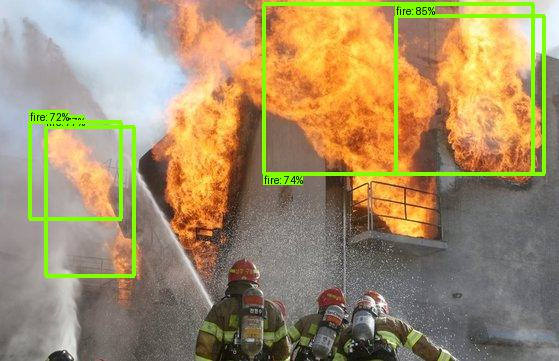

In [57]:
# Visualization

# image_dir = 'models/research/object_detection/test_images/'
# image_path = os.path.join(image_dir, 'image2.jpg')
image_dir = ROOT_FOLDER  + '/test_images'
image_path = os.path.join(image_dir, 'fire.jpg')
image_np = load_image_into_numpy_array(image_path)

# Things to try:
# Flip horizontally
# image_np = np.fliplr(image_np).copy()

# Convert image to grayscale
# image_np = np.tile(
#     np.mean(image_np, 2, keepdims=True), (1, 1, 3)).astype(np.uint8)

input_tensor = tf.convert_to_tensor(
    np.expand_dims(image_np, 0), dtype=tf.float32)
detections, predictions_dict, shapes = detect_fn(input_tensor)

label_id_offset = 1
image_np_with_detections = image_np.copy()

# # Use keypoints if available in detections
keypoints, keypoint_scores = None, None
if 'detection_keypoints' in detections:
    keypoints = detections['detection_keypoints'][0].numpy()
    keypoint_scores = detections['detection_keypoint_scores'][0].numpy()

# print(detections['detection_boxes'][0].numpy())
# print(detections['detection_classes'][0].numpy())
# print(detections['detection_scores'][0].numpy())

viz_utils.visualize_boxes_and_labels_on_image_array(
      image_np_with_detections,
      detections['detection_boxes'][0].numpy(),
      (detections['detection_classes'][0].numpy() + label_id_offset).astype(int),
      detections['detection_scores'][0].numpy(),
      category_index,
      use_normalized_coordinates=True,
      max_boxes_to_draw=200,
      # min_score_thresh를 적절히 설정
      min_score_thresh=.70,
      agnostic_mode=False,
      keypoints=keypoints,
      keypoint_scores=keypoint_scores,
      keypoint_edges=get_keypoint_tuples(configs['eval_config'])
      )

# print(type(image_np_with_detections), image_np_with_detections.shape)
tmp = Image.fromarray(image_np_with_detections)
tmp.save('./test_result.jpg')
ipython_image('./test_result.jpg')
# plt.figure(figsize=(12,16))
# plt.imshow(image_np_with_detections)
# plt.show()

